## Инициализация среды

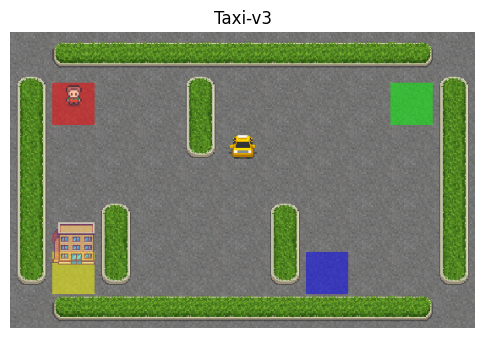

n_states=500, n_actions=6


In [12]:
import sys, os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("Taxi-v3", render_mode="rgb_array")
env.reset()

img = env.render()
plt.figure(figsize=(6, 6))
plt.axis('off')
plt.title("Taxi-v3")
plt.imshow(img)
plt.show()

n_states = env.observation_space.n
n_actions = env.action_space.n
print("n_states=%i, n_actions=%i" % (n_states, n_actions))

## Стохастическая политика

In [14]:
def initialize_policy(n_states, n_actions):
    policy = np.ones([n_states, n_actions]) / n_actions
    return policy

policy = initialize_policy(n_states, n_actions)

assert type(policy) in (np.ndarray, np.matrix)
assert np.allclose(policy, 1./n_actions)
assert np.allclose(np.sum(policy, axis=1), 1)

## Генерация сессий и визуализация начального распределения наград

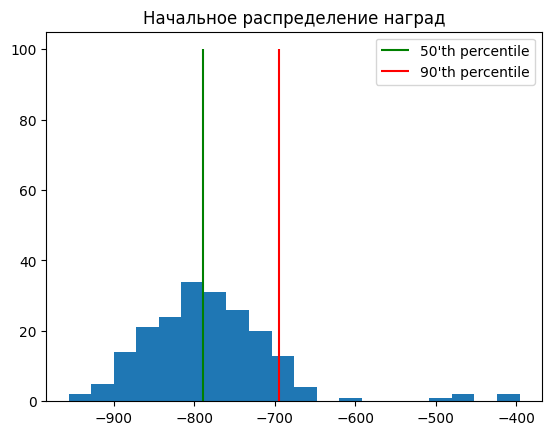

In [ ]:
def generate_session(env, policy, t_max=10**4):
    """ 
      Играть до конца или t_max тиков. 
     :param policy: массив вида [n_states,n_actions] с вероятностями действий 
     :returns: список состояний, список действий и сумма наград 
    """ 
    states, actions = [], []
    total_reward = 0.
    s, _ = env.reset()

    for t in range(t_max):
        a = np.random.choice(n_actions, p=policy[s])
        new_s, r, terminated, truncated, info = env.step(a)

        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward

s, a, r = generate_session(env, policy)
assert type(s) == type(a) == list
assert len(s) == len(a)
assert type(r) in [float, np.float64]

sample_rewards = [generate_session(env, policy, t_max=1000)[-1] for _ in range(200)]

plt.hist(sample_rewards, bins=20)
plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label="50'th percentile", color='green')
plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label="90'th percentile", color='red')
plt.title("Начальное распределение наград")
plt.legend()
plt.show()

## Шаги кросс-энтропийного метода

In [20]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Выберите состояния и действия из игры, которые имеют награды >= процентиль
    :paramstates_batch: список списков состояний,states_batch[session_i][t]
    :param action_batch: список списков действий, action_batch[session_i][t]
    :param rewards_batch: список наград, rewards_batch[session_i]
    :returns: elite_states,elite_actions, одномерные списки состояний и соответствующих действий
    лучших сессий
    """
    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = []
    elite_actions = []

    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
        if reward >= reward_threshold:
            elite_states.extend(states)
            elite_actions.extend(actions)

    return elite_states, elite_actions

states_batch = [ 
    [1, 2, 3],     # игра1  
    [4, 2, 0, 2],  # игра2 
    [3, 1],        # игра3 
] 
actions_batch = [ 
    [0, 2, 4],     # игра1 
    [3, 2, 0, 1],  # игра2 
    [3, 3],        # игра3 
] 
rewards_batch = [ 
    3,  # игра1 
    4,  # игра2 
    5,  # игра3 
] 

test_result_0 = select_elites(states_batch, actions_batch, rewards_batch, percentile=0) 
test_result_30 = select_elites(states_batch, actions_batch, rewards_batch, percentile=30) 
test_result_90 = select_elites(states_batch, actions_batch, rewards_batch, percentile=90) 
test_result_100 = select_elites(states_batch, actions_batch, rewards_batch, percentile=100) 

assert np.all(test_result_0[0] == [1, 2, 3, 4, 2, 0, 2, 3, 1]) \
       and np.all(test_result_0[1] == [0, 2, 4, 3, 2, 0, 1, 3, 3]), \
       "Для процентиля 0 вы должны вернуть все состояния и действия в хронологическом порядке."
assert np.all(test_result_30[0] == [4, 2, 0, 2, 3, 1]) and \
       np.all(test_result_30[1] == [3, 2, 0, 1, 3, 3]), \
       "Для процентиля 30 вы должны выбрать состояния/действия только из двух первых"
assert np.all(test_result_90[0] == [3, 1]) and \
       np.all(test_result_90[1] == [3, 3]), \
       "Для процентиля 90 вы должны выбирать состояния/действия только из одной игры."
assert np.all(test_result_100[0] == [3, 1]) and \
       np.all(test_result_100[1] == [3, 3]), \
       "Убедитесь, что вы используете >=, а не >. Также дважды проверьте, как вы вычисляете процентиль."

print("select_elites: все тесты пройдены.")

select_elites: все тесты пройдены.


## get_new_policy

In [21]:
def get_new_policy(elite_states, elite_actions):
    """ 
    Учитывая список лучших состояний/действий от select_elites, 
    возвращает новую политику, где вероятность каждого действия пропорциональна 
    policy[s_i,a_i] ~ #[появления s_i и a_i в элитарных состояниях/действиях] 
    Не забудьте нормализовать политику, чтобы получить действительные вероятности и обработать 
    случай 0/0. 
    Для состояний, в которых вы никогда не находились, используйте равномерное распределение 
    (1/n_actions для всех состояний). 
    :param Elite_states: одномерный список состояний лучших сессий. 
    :param Elite_actions: одномерный список действий лучших сессий. 
    """
    from collections import defaultdict
    new_policy = np.zeros([n_states, n_actions])

    for s, a in zip(elite_states, elite_actions):
        new_policy[s, a] += 1

    # Нормализация: где сумма > 0 — делим, иначе равномерное распределение
    for s in range(n_states):
        total = new_policy[s].sum()
        if total > 0:
            new_policy[s] /= total
        else:
            new_policy[s] = 1.0 / n_actions

    return new_policy

## Тренировочный цикл

mean reward = -43.556, threshold=4.000


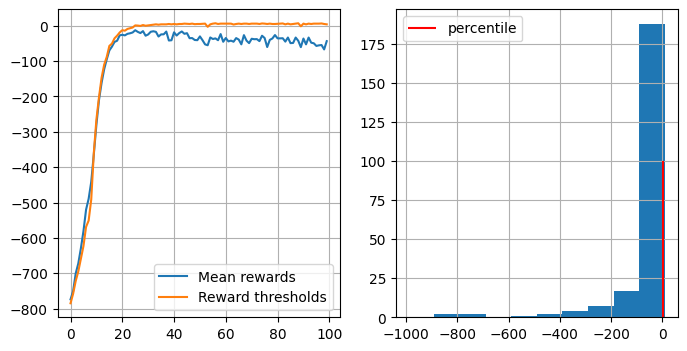

In [24]:
from IPython.display import clear_output

def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    Удобная функция, отображающая прогресс обучения
    """
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    plt.figure(figsize=[8, 4])

    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label='Mean rewards')
    plt.plot(list(zip(*log))[1], label='Reward thresholds')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines([np.percentile(rewards_batch, percentile)],
               [0], [100], label="percentile", color='red')
    plt.legend()
    plt.grid()

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.show()

policy = initialize_policy(n_states, n_actions)

n_sessions    = 250
percentile    = 50
learning_rate = 0.5
log = []

for i in range(100):
    sessions = [generate_session(env, policy) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile
    )

    new_policy = get_new_policy(elite_states, elite_actions)

    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    show_progress(rewards_batch, log, percentile)

Задача Taxi-v3 быстро сходится примерно к 15–20 итерации: средняя награда резко растёт с −800 до значений близких к нулю, так как кросс-энтропийный метод эффективно копирует даже редкие удачные траектории. Затем средняя награда стабилизируется с колебаниями в районе −50/−100, при percentile=50 алгоритм начинает отбирать средние, а не лучшие сессии, и политика постепенно ухудшается под их влиянием